In [89]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

In [90]:
api_url = "https://api.github.com/search/repositories?q=machine+learning&sort=stars&order=desc&per_page=100"

In [91]:
response = requests.get(api_url)
print("API response code: ", response.status_code)

API response code:  200


In [92]:
data = response.json()
all_df = pd.DataFrame(data["items"])

In [93]:
all_df.head()

,id,node_id,name,full_name,private,owner,html_url,description,fork,url,...,web_commit_signoff_required,has_pull_requests,pull_request_creation_policy,topics,visibility,forks,open_issues,watchers,default_branch,score
0,45717250,MDEwOlJlcG9zaXRvcnk0NTcxNzI1MA==,tensorflow,tensorflow/tensorflow,False,"{'login': 'tensorflow', 'id': 15658638, 'node_...",https://github.com/tensorflow/tensorflow,An Open Source Machine Learning Framework for ...,False,https://api.github.com/repos/tensorflow/tensor...,...,False,True,all,"[deep-learning, deep-neural-networks, distribu...",public,76044,2914,196978,master,1.0
1,155220641,MDEwOlJlcG9zaXRvcnkxNTUyMjA2NDE=,transformers,huggingface/transformers,False,"{'login': 'huggingface', 'id': 25720743, 'node...",https://github.com/huggingface/transformers,🤗 Transformers: the model-definition framework...,False,https://api.github.com/repos/huggingface/trans...,...,False,True,all,"[audio, deep-learning, deepseek, gemma, glm, h...",public,34259,2386,164190,main,1.0
2,343965132,MDEwOlJlcG9zaXRvcnkzNDM5NjUxMzI=,ML-For-Beginners,microsoft/ML-For-Beginners,False,"{'login': 'microsoft', 'id': 6154722, 'node_id...",https://github.com/microsoft/ML-For-Beginners,"12 weeks, 26 lessons, 52 quizzes, classic Mach...",False,https://api.github.com/repos/microsoft/ML-For-...,...,False,True,all,"[data-science, education, machine-learning, ma...",public,21956,11,89454,main,1.0
3,145553672,MDEwOlJlcG9zaXRvcnkxNDU1NTM2NzI=,funNLP,fighting41love/funNLP,False,"{'login': 'fighting41love', 'id': 11475294, 'n...",https://github.com/fighting41love/funNLP,中英文敏感词、语言检测、中外手机/电话归属地/运营商查询、名字推断性别、手机号抽取、身份证抽...,False,https://api.github.com/repos/fighting41love/fu...,...,False,True,all,[],public,15267,53,82513,master,1.0
4,21872392,MDEwOlJlcG9zaXRvcnkyMTg3MjM5Mg==,awesome-machine-learning,josephmisiti/awesome-machine-learning,False,"{'login': 'josephmisiti', 'id': 246302, 'node_...",https://github.com/josephmisiti/awesome-machin...,A curated list of awesome Machine Learning fra...,False,https://api.github.com/repos/josephmisiti/awes...,...,False,True,all,[],public,15610,24,74041,master,1.0


In [94]:
all_df.shape

(100, 82)

In [95]:
all_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 82 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            100 non-null    int64  
 1   node_id                       100 non-null    object 
 2   name                          100 non-null    object 
 3   full_name                     100 non-null    object 
 4   private                       100 non-null    bool   
 5   owner                         100 non-null    object 
 6   html_url                      100 non-null    object 
 7   description                   100 non-null    object 
 8   fork                          100 non-null    bool   
 9   url                           100 non-null    object 
 10  forks_url                     100 non-null    object 
 11  keys_url                      100 non-null    object 
 12  collaborators_url             100 non-null    object 
 13  teams_

In [96]:
all_df.columns

Index(['id', 'node_id', 'name', 'full_name', 'private', 'owner', 'html_url',
       'description', 'fork', 'url', 'forks_url', 'keys_url',
       'collaborators_url', 'teams_url', 'hooks_url', 'issue_events_url',
       'events_url', 'assignees_url', 'branches_url', 'tags_url', 'blobs_url',
       'git_tags_url', 'git_refs_url', 'trees_url', 'statuses_url',
       'languages_url', 'stargazers_url', 'contributors_url',
       'subscribers_url', 'subscription_url', 'commits_url', 'git_commits_url',
       'comments_url', 'issue_comment_url', 'contents_url', 'compare_url',
       'merges_url', 'archive_url', 'downloads_url', 'issues_url', 'pulls_url',
       'milestones_url', 'notifications_url', 'labels_url', 'releases_url',
       'deployments_url', 'created_at', 'updated_at', 'pushed_at', 'git_url',
       'ssh_url', 'clone_url', 'svn_url', 'homepage', 'size',
       'stargazers_count', 'watchers_count', 'language', 'has_issues',
       'has_projects', 'has_downloads', 'has_wiki', 'has

In [97]:
df = all_df[[
    "name",
    "owner",
    "language",
    "stargazers_count",
    "forks_count",
    "watchers_count",
    "open_issues_count",
    "created_at",
    "updated_at",
    "license"
]]

In [98]:
df["owner_login"] = all_df["owner"].apply(lambda x: x["login"] if x else None)

df["license_name"] = all_df["license"].apply(lambda x: x["name"] if x else None)

/tmp/ipykernel_520/2743034942.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["owner_login"] = all_df["owner"].apply(lambda x: x["login"] if x else None)
/tmp/ipykernel_520/2743034942.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["license_name"] = all_df["license"].apply(lambda x: x["name"] if x else None)


In [99]:
df.drop(columns=["owner", "license"], inplace=True)

/tmp/ipykernel_520/1309945446.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=["owner", "license"], inplace=True)


In [100]:
df.head()

,name,language,stargazers_count,forks_count,watchers_count,open_issues_count,created_at,updated_at,owner_login,license_name
0,tensorflow,C++,196978,76044,196978,2914,2015-11-07T01:19:20Z,2026-08-17T18:56:37Z,tensorflow,Apache License 2.0
1,transformers,Python,164190,34259,164190,2386,2018-10-29T13:56:00Z,2026-08-17T19:01:26Z,huggingface,Apache License 2.0
2,ML-For-Beginners,Jupyter Notebook,89454,21956,89454,11,2021-03-03T01:34:05Z,2026-08-17T17:48:19Z,microsoft,MIT License
3,funNLP,Python,82513,15267,82513,53,2018-08-21T11:20:39Z,2026-08-17T18:29:06Z,fighting41love,None
4,awesome-machine-learning,Python,74041,15610,74041,24,2014-07-15T19:11:19Z,2026-08-17T17:21:40Z,josephmisiti,Other


In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   name               100 non-null    object
 1   language           77 non-null     object
 2   stargazers_count   100 non-null    int64 
 3   forks_count        100 non-null    int64 
 4   watchers_count     100 non-null    int64 
 5   open_issues_count  100 non-null    int64 
 6   created_at         100 non-null    object
 7   updated_at         100 non-null    object
 8   owner_login        100 non-null    object
 9   license_name       78 non-null     object
dtypes: int64(4), object(6)
memory usage: 7.9+ KB


In [102]:
df['language'] =df['language'].fillna("Unknown")

/tmp/ipykernel_520/2935751595.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['language'] =df['language'].fillna("Unknown")


In [103]:
df["license_name"] = df["license_name"].fillna("Unknown")

/tmp/ipykernel_520/2553177735.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["license_name"] = df["license_name"].fillna("Unknown")


In [104]:
df.isnull().sum()

,0
name,0
language,0
stargazers_count,0
forks_count,0
watchers_count,0
open_issues_count,0
created_at,0
updated_at,0
owner_login,0
license_name,0


In [105]:
df.duplicated().sum()

np.int64(0)

In [106]:
df['created_at'] = pd.to_datetime(df['created_at'])
df['updated_at'] = pd.to_datetime(df['updated_at'])

/tmp/ipykernel_520/1444909529.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['created_at'] = pd.to_datetime(df['created_at'])
/tmp/ipykernel_520/1444909529.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['updated_at'] = pd.to_datetime(df['updated_at'])


In [107]:
df.rename(columns={
    "name": "names",
    "stargazers_count": "stars",
    "forks_count": "forks",
    "watchers_count": "watchers",
    "open_issues_count": "open_issues",
    "created_at": "created_date",
    "updated_at": "updated_date"
}, inplace=True)

/tmp/ipykernel_520/3543934274.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={


In [108]:
df.columns

Index(['names', 'language', 'stars', 'forks', 'watchers', 'open_issues',
       'created_date', 'updated_date', 'owner_login', 'license_name'],
      dtype='object')

In [109]:
df.to_csv("github_projects.csv")

---------
#**Task 2**
--------

In [110]:
!pip install ipython-sql==0.5.0 prettytable==3.9.0

%load_ext sql
%config SqlMagic.style = 'PLAIN_COLUMNS'
%sql sqlite:///library.db

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


In [111]:
GitHub_API = pd.read_csv("github_projects.csv")
GitHub_API.to_sql("GitHub_API", "sqlite:///library.db", if_exists="replace", index=False)

100

In [112]:
%%sql
SELECT *
FROM GitHub_API
LIMIT 8;

 * sqlite:///library.db
Done.


Unnamed: 0,names,language,stars,forks,watchers,open_issues,created_date,updated_date,owner_login,license_name
0,tensorflow,C++,196978,76044,196978,2914,2015-11-07 01:19:20+00:00,2026-08-17 18:56:37+00:00,tensorflow,Apache License 2.0
1,transformers,Python,164190,34259,164190,2386,2018-10-29 13:56:00+00:00,2026-08-17 19:01:26+00:00,huggingface,Apache License 2.0
2,ML-For-Beginners,Jupyter Notebook,89454,21956,89454,11,2021-03-03 01:34:05+00:00,2026-08-17 17:48:19+00:00,microsoft,MIT License
3,funNLP,Python,82513,15267,82513,53,2018-08-21 11:20:39+00:00,2026-08-17 18:29:06+00:00,fighting41love,Unknown
4,awesome-machine-learning,Python,74041,15610,74041,24,2014-07-15 19:11:19+00:00,2026-08-17 17:21:40+00:00,josephmisiti,Other
5,scikit-learn,Python,66962,27293,66962,2126,2010-08-17 09:43:38+00:00,2026-08-17 18:20:53+00:00,scikit-learn,"BSD 3-Clause ""New"" or ""Revised"" License"
6,gradio,Python,43376,3575,43376,181,2018-12-19 08:24:04+00:00,2026-08-17 18:47:15+00:00,gradio-app,Apache License 2.0
7,500-AI-Machine-learning-Deep-learning-Computer-vision-NLP-Projects-with-code,Unknown,36338,7438,36338,67,2021-01-02 12:08:37+00:00,2026-08-17 17:53:01+00:00,ashishpatel26,Unknown


In [113]:
%%sql
SELECT *
FROM GitHub_API
WHERE stars > 10000;

 * sqlite:///library.db
Done.


Unnamed: 0,names,language,stars,forks,watchers,open_issues,created_date,updated_date,owner_login,license_name
0,tensorflow,C++,196978,76044,196978,2914,2015-11-07 01:19:20+00:00,2026-08-17 18:56:37+00:00,tensorflow,Apache License 2.0
1,transformers,Python,164190,34259,164190,2386,2018-10-29 13:56:00+00:00,2026-08-17 19:01:26+00:00,huggingface,Apache License 2.0
2,ML-For-Beginners,Jupyter Notebook,89454,21956,89454,11,2021-03-03 01:34:05+00:00,2026-08-17 17:48:19+00:00,microsoft,MIT License
3,funNLP,Python,82513,15267,82513,53,2018-08-21 11:20:39+00:00,2026-08-17 18:29:06+00:00,fighting41love,Unknown
4,awesome-machine-learning,Python,74041,15610,74041,24,2014-07-15 19:11:19+00:00,2026-08-17 17:21:40+00:00,josephmisiti,Other
5,scikit-learn,Python,66962,27293,66962,2126,2010-08-17 09:43:38+00:00,2026-08-17 18:20:53+00:00,scikit-learn,"BSD 3-Clause ""New"" or ""Revised"" License"
6,gradio,Python,43376,3575,43376,181,2018-12-19 08:24:04+00:00,2026-08-17 18:47:15+00:00,gradio-app,Apache License 2.0
7,500-AI-Machine-learning-Deep-learning-Computer-vision-NLP-Projects-with-code,Unknown,36338,7438,36338,67,2021-01-02 12:08:37+00:00,2026-08-17 17:53:01+00:00,ashishpatel26,Unknown
8,C-Plus-Plus,C++,34582,7850,34582,31,2016-07-16 10:19:45+00:00,2026-08-17 15:41:11+00:00,TheAlgorithms,MIT License
9,netron,JavaScript,33363,3173,33363,16,2010-12-26 12:53:43+00:00,2026-08-17 18:17:22+00:00,lutzroeder,MIT License


In [114]:
%%sql
SELECT *
FROM GitHub_API
WHERE names LIKE '%Machine%';


 * sqlite:///library.db
Done.


Unnamed: 0,names,language,stars,forks,watchers,open_issues,created_date,updated_date,owner_login,license_name
4,awesome-machine-learning,Python,74041,15610,74041,24,2014-07-15 19:11:19+00:00,2026-08-17 17:21:40+00:00,josephmisiti,Other
7,500-AI-Machine-learning-Deep-learning-Computer-vision-NLP-Projects-with-code,Unknown,36338,7438,36338,67,2021-01-02 12:08:37+00:00,2026-08-17 17:53:01+00:00,ashishpatel26,Unknown
12,machine-learning-for-software-engineers,Unknown,28859,6148,28859,32,2016-10-09 21:20:25+00:00,2026-08-17 08:46:18+00:00,ZuzooVn,Creative Commons Attribution Share Alike 4.0 International
16,homemade-machine-learning,Jupyter Notebook,24759,4194,24759,31,2018-11-01 04:34:19+00:00,2026-08-17 04:12:18+00:00,trekhleb,MIT License
23,awesome-production-machine-learning,Unknown,20851,2590,20851,31,2018-08-15 14:28:41+00:00,2026-08-17 10:03:25+00:00,EthicalML,MIT License
24,machine-learning-for-trading,Jupyter Notebook,20490,5521,20490,6,2018-05-09 12:33:08+00:00,2026-08-17 18:56:12+00:00,stefan-jansen,MIT License
25,stanford-cs-229-machine-learning,Unknown,20118,4248,20118,20,2018-08-04 23:01:00+00:00,2026-08-17 17:33:23+00:00,afshinea,MIT License
29,Machine-Learning-Tutorials,Unknown,18107,3970,18107,47,2015-09-12 14:51:38+00:00,2026-08-17 14:27:22+00:00,ujjwalkarn,Creative Commons Zero v1.0 Universal
48,machine-learning-zoomcamp,Jupyter Notebook,13928,3092,13928,3,2020-04-17 04:29:23+00:00,2026-08-17 17:14:13+00:00,DataTalksClub,Unknown
52,machine-learning-interview,Unknown,12782,2043,12782,9,2020-08-11 06:26:32+00:00,2026-08-17 10:04:18+00:00,khangich,Unknown


In [115]:
%%sql
SELECT *
FROM GitHub_API
WHERE language = "Python" AND stars >10000

 * sqlite:///library.db
Done.


Unnamed: 0,names,language,stars,forks,watchers,open_issues,created_date,updated_date,owner_login,license_name
1,transformers,Python,164190,34259,164190,2386,2018-10-29 13:56:00+00:00,2026-08-17 19:01:26+00:00,huggingface,Apache License 2.0
3,funNLP,Python,82513,15267,82513,53,2018-08-21 11:20:39+00:00,2026-08-17 18:29:06+00:00,fighting41love,Unknown
4,awesome-machine-learning,Python,74041,15610,74041,24,2014-07-15 19:11:19+00:00,2026-08-17 17:21:40+00:00,josephmisiti,Other
5,scikit-learn,Python,66962,27293,66962,2126,2010-08-17 09:43:38+00:00,2026-08-17 18:20:53+00:00,scikit-learn,"BSD 3-Clause ""New"" or ""Revised"" License"
6,gradio,Python,43376,3575,43376,181,2018-12-19 08:24:04+00:00,2026-08-17 18:47:15+00:00,gradio-app,Apache License 2.0
10,ML-From-Scratch,Python,32483,5431,32483,78,2017-02-05 12:11:23+00:00,2026-08-17 13:37:22+00:00,eriklindernoren,MIT License
13,linkedin-skill-assessments-quizzes,Python,28813,12908,28813,21,2019-07-13 19:52:56+00:00,2026-08-16 21:12:22+00:00,Ebazhanov,GNU Affero General Public License v3.0
14,cs249r_book,Python,27943,3528,27943,49,2023-09-06 19:31:06+00:00,2026-08-17 19:00:32+00:00,harvard-edge,Other
20,onnx,Python,21321,4000,21321,282,2017-09-07 04:53:45+00:00,2026-08-17 18:35:55+00:00,onnx,Apache License 2.0
21,rasa,Python,21296,4919,21296,153,2016-10-14 12:27:49+00:00,2026-08-16 11:07:02+00:00,RasaHQ,Apache License 2.0


In [116]:
%%sql
SELECT *
FROM GitHub_API
WHERE license_name = 'MIT License' OR language =  'C++'

 * sqlite:///library.db
Done.


Unnamed: 0,names,language,stars,forks,watchers,open_issues,created_date,updated_date,owner_login,license_name
0,tensorflow,C++,196978,76044,196978,2914,2015-11-07 01:19:20+00:00,2026-08-17 18:56:37+00:00,tensorflow,Apache License 2.0
2,ML-For-Beginners,Jupyter Notebook,89454,21956,89454,11,2021-03-03 01:34:05+00:00,2026-08-17 17:48:19+00:00,microsoft,MIT License
8,C-Plus-Plus,C++,34582,7850,34582,31,2016-07-16 10:19:45+00:00,2026-08-17 15:41:11+00:00,TheAlgorithms,MIT License
9,netron,JavaScript,33363,3173,33363,16,2010-12-26 12:53:43+00:00,2026-08-17 18:17:22+00:00,lutzroeder,MIT License
10,ML-From-Scratch,Python,32483,5431,32483,78,2017-02-05 12:11:23+00:00,2026-08-17 13:37:22+00:00,eriklindernoren,MIT License
11,applied-ml,Unknown,30060,3991,30060,8,2020-07-04 18:57:47+00:00,2026-08-17 19:00:47+00:00,eugeneyan,MIT License
15,shap,Jupyter Notebook,25689,3741,25689,1012,2016-11-22 19:17:08+00:00,2026-08-17 18:50:13+00:00,shap,MIT License
16,homemade-machine-learning,Jupyter Notebook,24759,4194,24759,31,2018-11-01 04:34:19+00:00,2026-08-17 04:12:18+00:00,trekhleb,MIT License
17,Paddle,C++,24054,6014,24054,1520,2016-08-15 06:59:08+00:00,2026-08-17 09:26:29+00:00,PaddlePaddle,Apache License 2.0
22,video2x,C++,20951,1815,20951,130,2018-02-24 16:34:41+00:00,2026-08-17 11:09:37+00:00,k4yt3x,GNU Affero General Public License v3.0


In [117]:
%%sql
SELECT *
FROM GitHub_API
WHERE NOT language = 'Python'

 * sqlite:///library.db
Done.


Unnamed: 0,names,language,stars,forks,watchers,open_issues,created_date,updated_date,owner_login,license_name
0,tensorflow,C++,196978,76044,196978,2914,2015-11-07 01:19:20+00:00,2026-08-17 18:56:37+00:00,tensorflow,Apache License 2.0
2,ML-For-Beginners,Jupyter Notebook,89454,21956,89454,11,2021-03-03 01:34:05+00:00,2026-08-17 17:48:19+00:00,microsoft,MIT License
7,500-AI-Machine-learning-Deep-learning-Computer-vision-NLP-Projects-with-code,Unknown,36338,7438,36338,67,2021-01-02 12:08:37+00:00,2026-08-17 17:53:01+00:00,ashishpatel26,Unknown
8,C-Plus-Plus,C++,34582,7850,34582,31,2016-07-16 10:19:45+00:00,2026-08-17 15:41:11+00:00,TheAlgorithms,MIT License
9,netron,JavaScript,33363,3173,33363,16,2010-12-26 12:53:43+00:00,2026-08-17 18:17:22+00:00,lutzroeder,MIT License
11,applied-ml,Unknown,30060,3991,30060,8,2020-07-04 18:57:47+00:00,2026-08-17 19:00:47+00:00,eugeneyan,MIT License
12,machine-learning-for-software-engineers,Unknown,28859,6148,28859,32,2016-10-09 21:20:25+00:00,2026-08-17 08:46:18+00:00,ZuzooVn,Creative Commons Attribution Share Alike 4.0 International
15,shap,Jupyter Notebook,25689,3741,25689,1012,2016-11-22 19:17:08+00:00,2026-08-17 18:50:13+00:00,shap,MIT License
16,homemade-machine-learning,Jupyter Notebook,24759,4194,24759,31,2018-11-01 04:34:19+00:00,2026-08-17 04:12:18+00:00,trekhleb,MIT License
17,Paddle,C++,24054,6014,24054,1520,2016-08-15 06:59:08+00:00,2026-08-17 09:26:29+00:00,PaddlePaddle,Apache License 2.0


In [118]:
%%sql
SELECT names, stars
FROM GitHub_API
ORDER BY stars DESC
LIMIT 10

 * sqlite:///library.db
Done.


names,stars
tensorflow,196978
transformers,164190
ML-For-Beginners,89454
funNLP,82513
awesome-machine-learning,74041
scikit-learn,66962
gradio,43376
500-AI-Machine-learning-Deep-learning-Computer-vision-NLP-Projects-with-code,36338
C-Plus-Plus,34582
netron,33363


In [119]:
%%sql
SELECT COUNT(*) AS total_number_of_repositories
FROM GitHub_API;

 * sqlite:///library.db
Done.


total_number_of_repositories
100


In [120]:
%%sql
SELECT AVG(stars) AS average_number_of_stars
FROM GitHub_API;

 * sqlite:///library.db
Done.


average_number_of_stars
20798.4


In [121]:
%%sql
SELECT language,COUNT(*) AS total_number_of_repositories
FROM GitHub_API
GROUP BY language
HAVING COUNT(*) > 5;

 * sqlite:///library.db
Done.


language,total_number_of_repositories
C++,12
Jupyter Notebook,19
Python,30
Unknown,23


In [122]:
result = %sql SELECT names, stars FROM GitHub_API ORDER BY stars DESC LIMIT 10

 * sqlite:///library.db
Done.


In [123]:
df_top10 = result.DataFrame()
df_top10

,names,stars
0,tensorflow,196978
1,transformers,164190
2,ML-For-Beginners,89454
3,funNLP,82513
4,awesome-machine-learning,74041
5,scikit-learn,66962
6,gradio,43376
7,500-AI-Machine-learning-Deep-learning-Computer...,36338
8,C-Plus-Plus,34582
9,netron,33363


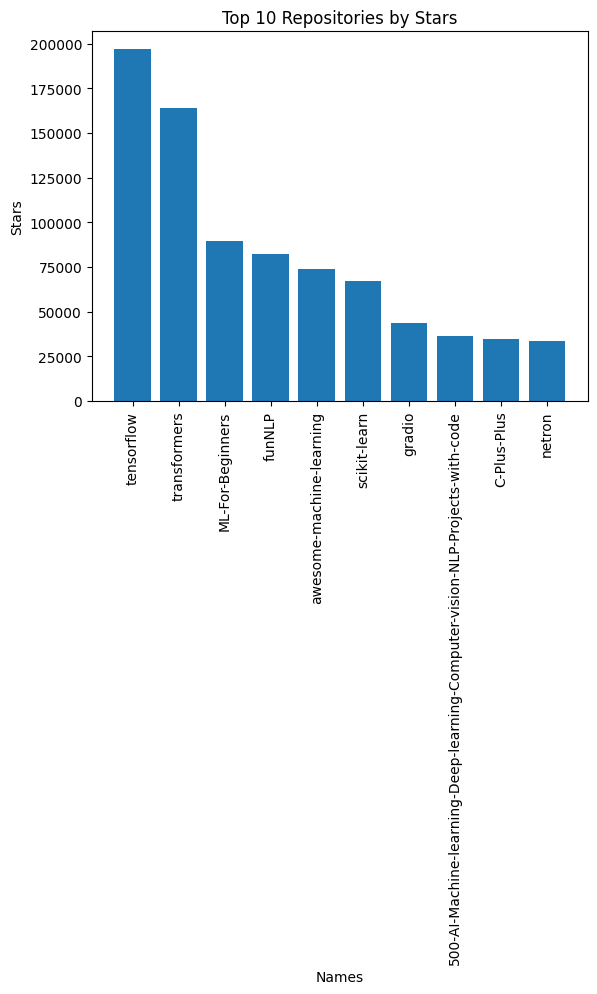

In [124]:
plt.bar(df_top10['names'], df_top10['stars'])
plt.xlabel('Names')
plt.ylabel('Stars')
plt.title('Top 10 Repositories by Stars')
plt.xticks(rotation=90)
plt.show()

In [125]:
repo = %sql SELECT strftime('%Y', created_date), COUNT(*) AS total_number_of_repositories FROM GitHub_API GROUP BY strftime('%Y', created_date);

 * sqlite:///library.db
Done.


In [126]:
repo_year = repo.DataFrame()
repo_year.rename(columns={'strftime(\'%Y\', created_date)': 'year'}, inplace=True)
repo_year

,year,total_number_of_repositories
0,2009,1
1,2010,2
2,2011,2
3,2013,3
4,2014,6
5,2015,7
6,2016,14
7,2017,17
8,2018,18
9,2019,7


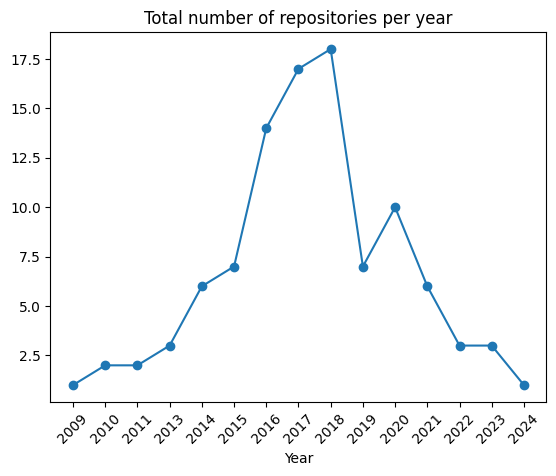

In [127]:
plt.plot(repo_year['year'], repo_year['total_number_of_repositories'], marker='o')
plt.xlabel('Year')
plt.title('Total number of repositories per year')
plt.xticks(rotation=45)
plt.show()


#**Interpret Results**

1. **TensorFlow is the most popular repository**, with significantly more stars than the other repositories in the Top 10.

2. **Transformers is the second most popular repository**, with a large number of stars compared to most of the other repositories.

3. **Most of the Top 10 repositories have fewer than 100,000 stars**, while TensorFlow and Transformers stand out with significantly higher popularity.

4. **Repository creation increased significantly between 2014 and 2018**, reaching the highest number of newly created repositories in 2018.

5. **After 2018, repository creation generally decreased**, with a noticeable increase again in 2020.


# Step 7: Ethics Reflection

### 1. Why is it important to verify data collected from public APIs?

It is important to verify data collected from public APIs because the data may contain missing, inaccurate, outdated, or inconsistent information. Verifying the data helps ensure that the analysis is based on reliable and accurate information.

### 2. Why should data analysts document the source of their data?

Data analysts should document the source of their data to make the analysis transparent and reproducible. Documenting the API source allows others to understand where the data came from, verify the results, and reproduce the analysis if needed.

### 3. How can missing or inaccurate data affect data analysis and decision-making?

Missing or inaccurate data can lead to incorrect results, misleading patterns, and unreliable conclusions. This can affect decision-making because decisions based on poor-quality data may not accurately represent the real situation.
